# Visualization of Multi-BLEU Scores

## Setup

In [1]:
import re
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
ROOT = Path("..").resolve()

BASELINE_DIR = ROOT / "baseline"
BASELINE2_DIR = ROOT / "baseline2"

IMG_DIR = ROOT / "img"
SUMMARY_DIR = ROOT / "summary"

## Extract Scores

### 1st end-to-end SMT: run1 + run2 + run3

In [3]:
%cd {BASELINE_DIR}/my-ph/evaluation
!cat test.multi-bleu.2

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/my-ph/evaluation
BLEU = 69.14, 85.2/72.4/64.3/57.6 (BP=1.000, ratio=1.000, hyp_len=8050, ref_len=8048)


In [4]:
%cd {BASELINE_DIR}/ph-my/evaluation
!cat test.multi-bleu.2

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline/ph-my/evaluation
BLEU = 78.15, 87.8/79.4/75.0/71.3 (BP=1.000, ratio=1.000, hyp_len=8047, ref_len=8048)


### 2nd end-to-end SMT: run4

In [5]:
%cd {BASELINE2_DIR}/my-ph/evaluation
!cat test.multi-bleu.1

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation


BLEU = 69.49, 85.2/72.6/64.8/58.2 (BP=1.000, ratio=1.000, hyp_len=8050, ref_len=8048)


In [6]:
%cd {BASELINE2_DIR}/ph-my/evaluation
!cat test.multi-bleu.1

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/evaluation
BLEU = 78.44, 87.8/79.6/75.6/71.7 (BP=1.000, ratio=1.000, hyp_len=8046, ref_len=8048)


### 3rd end-to-end SMT: run5

In [7]:
%cd {BASELINE2_DIR}/my-ph/evaluation
!cat test.multi-bleu.2

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation
BLEU = 69.25, 85.3/72.7/64.7/57.4 (BP=1.000, ratio=1.000, hyp_len=8050, ref_len=8048)


In [8]:
%cd {BASELINE2_DIR}/ph-my/evaluation
!cat test.multi-bleu.2

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/evaluation
BLEU = 78.45, 87.9/79.7/75.6/71.7 (BP=1.000, ratio=1.000, hyp_len=8046, ref_len=8048)


### 4th end-to-end SMT: run6

In [9]:
%cd {BASELINE2_DIR}/my-ph/evaluation
!cat test.multi-bleu.3

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation
BLEU = 69.46, 85.1/72.5/64.2/58.8 (BP=1.000, ratio=1.000, hyp_len=8051, ref_len=8048)


In [10]:
%cd {BASELINE2_DIR}/ph-my/evaluation
!cat test.multi-bleu.3

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/evaluation
BLEU = 78.31, 87.9/79.6/75.4/71.4 (BP=1.000, ratio=1.000, hyp_len=8045, ref_len=8048)


### 5th end-to-end SMT: run7

In [11]:
%cd {BASELINE2_DIR}/my-ph/evaluation
!cat test.multi-bleu.4

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation
BLEU = 69.88, 85.3/72.8/65.0/59.1 (BP=1.000, ratio=1.000, hyp_len=8050, ref_len=8048)


In [12]:
%cd {BASELINE2_DIR}/ph-my/evaluation
!cat test.multi-bleu.4

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/evaluation
BLEU = 78.30, 87.7/79.3/75.4/71.8 (BP=1.000, ratio=1.000, hyp_len=8045, ref_len=8048)


### 6th end-to-end SMT: run8

In [13]:
%cd {BASELINE2_DIR}/my-ph/evaluation
!cat test.multi-bleu.5

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/my-ph/evaluation
BLEU = 69.71, 85.1/72.7/65.0/58.7 (BP=1.000, ratio=1.000, hyp_len=8050, ref_len=8048)


In [14]:
%cd {BASELINE2_DIR}/ph-my/evaluation
!cat test.multi-bleu.5
%cd {ROOT}

/home/lawun330/Desktop/basic-statistical-machine-translation/baseline2/ph-my/evaluation
BLEU = 78.41, 87.8/79.5/75.5/71.8 (BP=1.000, ratio=1.000, hyp_len=8045, ref_len=8048)
/home/lawun330/Desktop/basic-statistical-machine-translation


## Helpers

In [15]:
# project runs -> (baseline dir, EMS step, label)
RUNS = [
    {"run": 1, "root": BASELINE_DIR,  "step": 2, "experiment": "run1–3 baseline"},
    {"run": 2, "root": BASELINE2_DIR, "step": 1, "experiment": "run4 new normalization"},
    {"run": 3, "root": BASELINE2_DIR, "step": 2, "experiment": "run5 3-gram LM"},
    {"run": 4, "root": BASELINE2_DIR, "step": 3, "experiment": "run6 max-phrase 3"},
    {"run": 5, "root": BASELINE2_DIR, "step": 4, "experiment": "run7 less prune"},
    {"run": 6, "root": BASELINE2_DIR, "step": 5, "experiment": "run8 MGIZA"},
]

DIRECTIONS = ("my-ph", "ph-my")

MULTI_BLEU_RE = re.compile(
    r"BLEU = ([\d.]+), "
    r"([\d.]+)/([\d.]+)/([\d.]+)/([\d.]+) "
    r"\(BP=([\d.]+), ratio=([\d.]+), hyp_len=(\d+), ref_len=(\d+)\)"
)

In [16]:
def parse_multi_bleu(text: str) -> dict:
    """Parse one line from Moses multi-bleu.perl output."""
    line = text.strip()
    if not line:
        raise ValueError("empty BLEU text")
    m = MULTI_BLEU_RE.search(line)
    if not m:
        raise ValueError(f"cannot parse multi-BLEU line: {line!r}")
    bleu, p1, p2, p3, p4, bp, ratio, hyp_len, ref_len = m.groups()
    return {
        "bleu": float(bleu),
        "n1": float(p1),
        "n2": float(p2),
        "n3": float(p3),
        "n4": float(p4),
        "bp": float(bp),
        "ratio": float(ratio),
        "hyp_len": int(hyp_len),
        "ref_len": int(ref_len),
    }


def multi_bleu_path(
    baseline_root: Path,
    direction: str,
    step: int,
    *,
    prefix: str = "test",
) -> Path:
    """Path to evaluation/test.multi-bleu.<step>."""
    return baseline_root / direction / "evaluation" / f"{prefix}.multi-bleu.{step}"


def load_multi_bleu(path: Path | str) -> dict:
    """Read and parse a test.multi-bleu.* file."""
    path = Path(path)
    text = path.read_text(encoding="utf-8")
    row = parse_multi_bleu(text)
    row["path"] = str(path.resolve())
    return row


def load_direction_step(
    baseline_root: Path,
    direction: str,
    step: int,
    *,
    run: int | None = None,
    experiment: str | None = None,
) -> dict:
    """Load one direction + EMS step; attach run metadata."""
    path = multi_bleu_path(baseline_root, direction, step)
    row = load_multi_bleu(path)
    row["direction"] = direction
    row["step"] = step
    row["baseline_root"] = baseline_root.name
    if run is not None:
        row["run"] = run
    if experiment is not None:
        row["experiment"] = experiment
    return row

In [17]:
def load_run(cfg: dict, directions: tuple[str, ...] = DIRECTIONS) -> list[dict]:
    """Load my-ph and ph-my for one project run."""
    rows = []
    for direction in directions:
        rows.append(
            load_direction_step(
                cfg["root"],
                direction,
                cfg["step"],
                run=cfg["run"],
                experiment=cfg["experiment"],
            )
        )
    return rows

In [18]:
def build_bleu_df(
    runs: list[dict] = RUNS,
    directions: tuple[str, ...] = DIRECTIONS,
) -> pd.DataFrame:
    """
    Long-format table: one row per (run, direction).
    Columns: run, experiment, direction, step, baseline_root, bleu, n1–n4, bp, ratio, hyp_len, ref_len, path
    """
    rows = []
    for cfg in runs:
        rows.extend(load_run(cfg, directions))
    df = pd.DataFrame(rows)
    col_order = [
        "run", "experiment", "direction", "step", "baseline_root",
        "bleu", "n1", "n2", "n3", "n4", "bp", "ratio", "hyp_len", "ref_len", "path",
    ]
    return df[[c for c in col_order if c in df.columns]]


def bleu_pivot(df: pd.DataFrame, value: str = "bleu") -> pd.DataFrame:
    """Wide table: index = experiment, columns = my-ph / ph-my."""
    return df.pivot(index=["run", "experiment"], columns="direction", values=value)

## Transform Scores

In [19]:
df = build_bleu_df()
df

,run,experiment,direction,step,baseline_root,bleu,n1,n2,n3,n4,bp,ratio,hyp_len,ref_len,path
0,1,run1–3 baseline,my-ph,2,baseline,69.14,85.2,72.4,64.3,57.6,1.0,1.0,8050,8048,/home/lawun330/Desktop/basic-statistical-machi...
1,1,run1–3 baseline,ph-my,2,baseline,78.15,87.8,79.4,75.0,71.3,1.0,1.0,8047,8048,/home/lawun330/Desktop/basic-statistical-machi...
2,2,run4 new normalization,my-ph,1,baseline2,69.49,85.2,72.6,64.8,58.2,1.0,1.0,8050,8048,/home/lawun330/Desktop/basic-statistical-machi...
3,2,run4 new normalization,ph-my,1,baseline2,78.44,87.8,79.6,75.6,71.7,1.0,1.0,8046,8048,/home/lawun330/Desktop/basic-statistical-machi...
4,3,run5 3-gram LM,my-ph,2,baseline2,69.25,85.3,72.7,64.7,57.4,1.0,1.0,8050,8048,/home/lawun330/Desktop/basic-statistical-machi...
5,3,run5 3-gram LM,ph-my,2,baseline2,78.45,87.9,79.7,75.6,71.7,1.0,1.0,8046,8048,/home/lawun330/Desktop/basic-statistical-machi...
6,4,run6 max-phrase 3,my-ph,3,baseline2,69.46,85.1,72.5,64.2,58.8,1.0,1.0,8051,8048,/home/lawun330/Desktop/basic-statistical-machi...
7,4,run6 max-phrase 3,ph-my,3,baseline2,78.31,87.9,79.6,75.4,71.4,1.0,1.0,8045,8048,/home/lawun330/Desktop/basic-statistical-machi...
8,5,run7 less prune,my-ph,4,baseline2,69.88,85.3,72.8,65.0,59.1,1.0,1.0,8050,8048,/home/lawun330/Desktop/basic-statistical-machi...
9,5,run7 less prune,ph-my,4,baseline2,78.30,87.7,79.3,75.4,71.8,1.0,1.0,8045,8048,/home/lawun330/Desktop/basic-statistical-machi...


In [20]:
df.to_csv(SUMMARY_DIR / "bleu_scores.csv", index=False)

In [21]:
bleu_pivot(df)

,direction,my-ph,ph-my
run,experiment,,
1,run1–3 baseline,69.14,78.15
2,run4 new normalization,69.49,78.44
3,run5 3-gram LM,69.25,78.45
4,run6 max-phrase 3,69.46,78.31
5,run7 less prune,69.88,78.30
6,run8 MGIZA,69.71,78.41


In [22]:
bleu_pivot(df).to_csv(SUMMARY_DIR / "bleu_scores_pivot.csv")

## Visualize

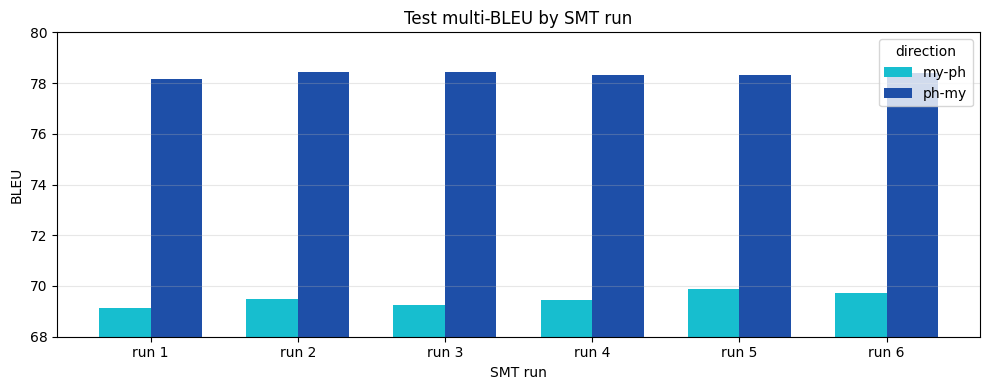

In [23]:
wide = bleu_pivot(df).reset_index()  # columns: run, experiment, my-ph, ph-my

# x-axis labels: short run numbers (edit if you prefer experiment text)
wide["label"] = wide["run"].map(lambda r: f"run {r}")

x = range(len(wide))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar([i - w/2 for i in x], wide["my-ph"], width=w, label="my-ph", color="#17BECF")
ax.bar([i + w/2 for i in x], wide["ph-my"], width=w, label="ph-my", color="#1E4FA8")

ax.set_xticks(x)
ax.set_xticklabels(wide["label"], rotation=0)
ax.set_xlabel("SMT run")
ax.set_ylabel("BLEU")
ax.set_title("Test multi-BLEU by SMT run")

ax.legend(title="direction")
ax.set_ylim(68, 80)  # tweak or remove
ax.grid(axis="y", alpha=0.3)

fig.savefig(IMG_DIR / "bleu_bars.png", dpi=150, bbox_inches="tight")

plt.tight_layout()
plt.show()

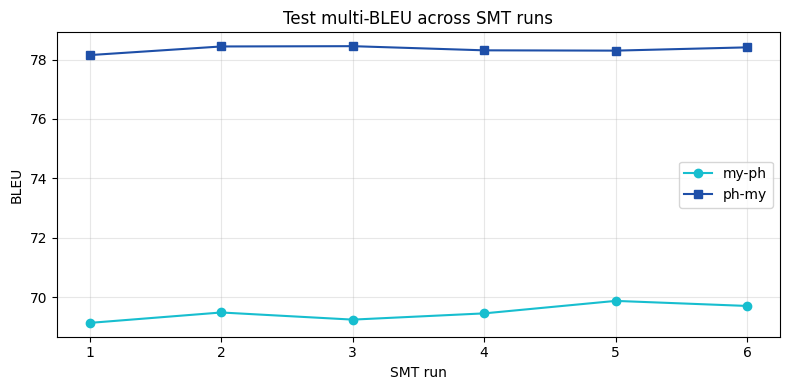

In [24]:
plot_df = df.sort_values("run")

colors = {
    "my-ph": "#17BECF",
    "ph-my": "#1E4FA8",
}

fig, ax = plt.subplots(figsize=(8, 4))

for direction, marker in [("my-ph", "o"), ("ph-my", "s")]:
    sub = plot_df[plot_df["direction"] == direction]
    ax.plot(sub["run"], sub["bleu"], marker=marker, label=direction, color=colors[direction])

ax.set_xticks(sorted(plot_df["run"].unique()))
ax.set_xlabel("SMT run")
ax.set_ylabel("BLEU")
ax.set_title("Test multi-BLEU across SMT runs")
ax.legend()
ax.grid(True, alpha=0.3)

fig.savefig(IMG_DIR / "bleu_lines.png", dpi=150, bbox_inches="tight")

plt.tight_layout()
plt.show()